# A2 Pileup Separator (Deltoro-style 1D-CAE)

A supervised separation model that takes a pileup waveform and outputs the
two individual component pulses. Architecture follows Deltoro et al. (NUCL SCI
TECH 2025): shared 1D-CNN encoder with two decoder branches, plus an
input-to-output residual skip connection.

**Input**: raw-voltage pileup waveform (104 samples)

**Outputs**: two raw-voltage waveforms — the primary pulse and the shifted
secondary pulse. By construction, output_1 + output_2 = input.

**Training data**: synthetic pileups from `generate_pileup.py`, where the
ground-truth components are stored as `primary_component` and
`secondary_component`.

**Normalization**: raw voltage (NOT L2). Separation needs amplitude info to
disentangle the two components.

**Evaluation**:
1. Shape correlation between reconstructed and true components
2. PSD (charge-comparison) ratio preservation — does the reconstructed pulse
   classify the same as the original single?

In [1]:
import os
os.makedirs('figures', exist_ok=True)

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1775972011.392278 3529320 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775972012.038652 3529320 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load data

Pileup waveforms and their ground-truth components, both in raw voltage.
No L2 normalization — the separator needs amplitude information.

In [2]:
d = np.load('pileup_waveforms.npz')
X_pileup = d['pileup_wf'].astype(np.float32)              # (N, 104)
Y_primary = d['primary_component'].astype(np.float32)      # (N, 104)
Y_secondary = d['secondary_component'].astype(np.float32)  # (N, 104)
primary_label = d['primary_label']                          # (N,)
secondary_label = d['secondary_label']                      # (N,)
delays = d['delays_samples']                                # (N,)

# Verify additivity: pileup = primary + secondary
resid = np.abs(X_pileup - (Y_primary + Y_secondary)).max()
print(f'Max additivity residual: {resid:.6f} (should be ~0)')

# Train/val/test split (60/20/20)
idx = np.arange(len(X_pileup))
idx_tv, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
idx_train, idx_val = train_test_split(idx_tv, test_size=0.25, random_state=42)

X_train, X_val, X_test = X_pileup[idx_train], X_pileup[idx_val], X_pileup[idx_test]
Y1_train, Y1_val, Y1_test = Y_primary[idx_train], Y_primary[idx_val], Y_primary[idx_test]
Y2_train, Y2_val, Y2_test = Y_secondary[idx_train], Y_secondary[idx_val], Y_secondary[idx_test]
delays_test = delays[idx_test]
pri_label_test = primary_label[idx_test]
sec_label_test = secondary_label[idx_test]

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Voltage range: [{X_pileup.min():.4f}, {X_pileup.max():.4f}] V')

# Verify class balance in pileup data
print(f'\nPair type balance:')
for pt, (p, s) in [('GG', (0, 0)), ('GN', (0, 1)), ('NG', (1, 0)), ('NN', (1, 1))]:
    n = ((primary_label == p) & (secondary_label == s)).sum()
    print(f'  {pt}: {n:,} ({n/len(primary_label)*100:.1f}%)')
print(f'  Primary:   photon={(primary_label==0).sum():,}  neutron={(primary_label==1).sum():,}')
print(f'  Secondary: photon={(secondary_label==0).sum():,}  neutron={(secondary_label==1).sum():,}')

Max additivity residual: 0.000000 (should be ~0)
Train: (104001, 104)  Val: (34668, 104)  Test: (34668, 104)
Voltage range: [-0.0087, 3.0505] V

Pair type balance:
  GG: 41,307 (23.8%)
  GN: 43,192 (24.9%)
  NG: 43,210 (24.9%)
  NN: 45,628 (26.3%)
  Primary:   photon=84,499  neutron=88,838
  Secondary: photon=84,517  neutron=88,820


## Separator architecture

Shared encoder → two decoder branches. Each decoder reconstructs one component.
An Add skip connection from the input to each output lets the model learn
residuals rather than full waveforms.

Architecture based on a2_tune best CNN (latent=32, [64,64] filters, kernel 3,
elu) but adapted for two-output separation.

In [3]:
N_SAMPLES = X_train.shape[1]  # 104

inputs = keras.Input(shape=(N_SAMPLES, 1), name='pileup_input')

# ── Shared encoder (Deltoro-style: small Conv1D + MaxPooling) ──
# Deliberately small — 5-16 channels. The model learns corrections, not full
# reconstructions. The Add skip at the end provides the base signal.
x = layers.Conv1D(16, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(2, padding='same')(x)    # 104 -> 52

x = layers.Conv1D(16, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)    # 52 -> 26

x = layers.Conv1D(16, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)    # 26 -> 13

encoded = x  # (13, 16) — shared between both decoders

# ── Decoder function (Deltoro-style) ──
# UpSampling + Conv1D (not ConvTranspose), then Flatten + Dense + Add(input).
# The Dense layer can learn arbitrary mappings, so the Add skip works even
# though it adds the full pileup — the Dense learns the correction needed.
def make_decoder(encoded_input, name_prefix):
    x = layers.UpSampling1D(2)(encoded_input)    # 13 -> 26
    x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)

    x = layers.UpSampling1D(2)(x)                 # 26 -> 52
    x = layers.Conv1D(16, 3, activation='relu', padding='same')(x)

    x = layers.UpSampling1D(2)(x)                 # 52 -> 104
    x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)

    # Flatten + Dense: fully connected mapping to output space
    x = layers.Flatten()(x)                        # 104 * 8 = 832
    x = layers.Dense(N_SAMPLES, activation='linear', name=f'{name_prefix}_dense')(x)

    # Deltoro-style: Add the raw input as a residual skip.
    # The Dense layer above learns the CORRECTION to the input.
    # With the Dense having full capacity, it can learn to output -secondary
    # (for the primary branch) so that Add(input) = pileup + (-secondary) = primary.
    inp_flat = layers.Lambda(lambda t: t[:, :, 0],
                             output_shape=(N_SAMPLES,))(inputs)
    out = layers.Add(name=name_prefix)([x, inp_flat])
    return out

output_primary   = make_decoder(encoded, 'primary')
output_secondary = make_decoder(encoded, 'secondary')

separator = Model(inputs, [output_primary, output_secondary], name='separator')

separator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={'primary': 'mse', 'secondary': 'mse'},
    loss_weights={'primary': 1.0, 'secondary': 1.0},
)

separator.summary()
print(f'\nTotal params: {separator.count_params():,}')

I0000 00:00:1775972013.613232 3529320 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8316 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "separator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pileup_input        │ (None, 104, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 104, 16)   │         64 │ pileup_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 52, 16)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 52, 16)    │        784 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 26, 16)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 26, 16)    │        784 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 13, 16)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d       │ (None, 26, 16)    │          0 │ max_pooling1d_2[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_3     │ (None, 26, 16)    │          0 │ max_pooling1d_2[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 26, 32)    │      1,568 │ up_sampling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 26, 32)    │      1,568 │ up_sampling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_1     │ (None, 52, 32)    │          0 │ conv1d_3[0][0]    │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_4     │ (None, 52, 32)    │          0 │ conv1d_6[0][0]    │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 52, 16)    │      1,552 │ up_sampling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 52, 16)    │      1,552 │ up_sampling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_2     │ (None, 104, 16)   │          0 │ conv1d_4[0][0]    │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_5     │ (None, 104, 16)   │          0 │ conv1d_7[0][0]    │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 104, 8)    │        392 │ up_sampling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 104, 8)    │        392 │ up_sampling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 832)       │          0 │ conv1d_5[0][0]  

 Total params: 181,920 (710.62 KB)

 Trainable params: 181,920 (710.62 KB)

 Non-trainable params: 0 (0.00 B)


Total params: 181,920


## Train

In [4]:
# Add channel dim for Conv1D input
X_train_3d = X_train[..., np.newaxis]
X_val_3d   = X_val[..., np.newaxis]
X_test_3d  = X_test[..., np.newaxis]

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=4, factor=0.5, verbose=1,
    ),
]

history = separator.fit(
    X_train_3d,
    {'primary': Y1_train, 'secondary': Y2_train},
    validation_data=(
        X_val_3d,
        {'primary': Y1_val, 'secondary': Y2_val},
    ),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
)

Epoch 1/100


I0000 00:00:1775972015.287849 3529535 service.cc:153] XLA service 0x79b7040063e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775972015.287861 3529535 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.8.0; DNN: 9.19.0)
I0000 00:00:1775972015.320412 3529535 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775972015.535554 3529535 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1775972015.544585 3529535 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4858__.46
I0000 00:00:1775972015.806993 3529696 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775972015.924427 3529691 subprocess_compilation.cc:348] ptxas wa

 83/407 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082 - primary_loss: 0.0045 - secondary_loss: 0.0037

I0000 00:00:1775972017.477726 3529535 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


385/407 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - primary_loss: 0.0021 - secondary_loss: 0.0015

I0000 00:00:1775972018.450550 3529539 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4858__.46
I0000 00:00:1775972018.882726 3530072 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 16 bytes spill stores, 16 bytes spill loads

E0000 00:00:1775972018.924908 3530094 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0034 - primary_loss: 0.0020 - secondary_loss: 0.0014

E0000 00:00:1775972020.480713 3530477 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775972020.588676 3530454 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775972021.158934 3530564 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


407/407 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0013 - primary_loss: 7.8148e-04 - secondary_loss: 4.7030e-04 - val_loss: 2.1980e-04 - val_primary_loss: 1.2533e-04 - val_secondary_loss: 9.4839e-05 - learning_rate: 0.0010
Epoch 2/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7073e-04 - primary_loss: 9.7953e-05 - secondary_loss: 7.2670e-05 - val_loss: 1.5328e-04 - val_primary_loss: 8.5691e-05 - val_secondary_loss: 6.7888e-05 - learning_rate: 0.0010
Epoch 3/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4115e-04 - primary_loss: 7.9537e-05 - secondary_loss: 6.1995e-05 - val_loss: 1.9859e-04 - val_primary_loss: 1.1161e-04 - val_secondary_loss: 8.7371e-05 - learning_rate: 0.0010
Epoch 4/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2136e-04 - primary_loss: 6.7920e-05 - secondary_loss: 5.3416e-05 - val_loss: 1.2005e-04 - val_primary_loss: 6.6167e-05 - val_secondary_loss: 5.4091e-05 - learning_rate: 0.0010
Epoch 5/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss

## Training curves

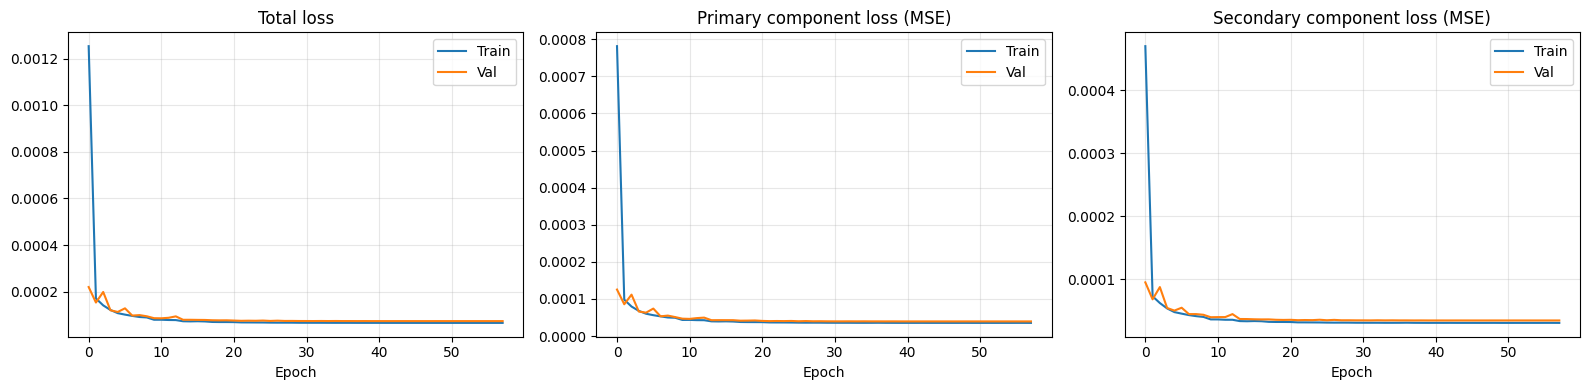

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Total loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['primary_loss'], label='Train')
axes[1].plot(history.history['val_primary_loss'], label='Val')
axes[1].set_title('Primary component loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['secondary_loss'], label='Train')
axes[2].plot(history.history['val_secondary_loss'], label='Val')
axes[2].set_title('Secondary component loss (MSE)')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/a2_separator_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Evaluate separated components with A1 classifier

Instead of analytical PSD (charge integration), we use the trained A1 singles
classifier to identify each separated component as neutron or photon. This is
the full ML pipeline:

1. A2 separator produces two raw-voltage components from each pileup
2. Each component is L2-normalized (matching A1's training normalization)
3. The A1 multi-task model classifies each as neutron (1) or photon (0)
4. Compare predictions against the true labels from the synthetic pileup data

In [6]:
pred_primary, pred_secondary = separator.predict(X_test_3d, batch_size=1024)

# Shape correlation (Pearson) per waveform
def row_correlation(A, B):
    A_centered = A - A.mean(axis=1, keepdims=True)
    B_centered = B - B.mean(axis=1, keepdims=True)
    num = (A_centered * B_centered).sum(axis=1)
    den = np.sqrt((A_centered**2).sum(axis=1) * (B_centered**2).sum(axis=1))
    return np.where(den > 0, num / den, 0.0)

corr_primary = row_correlation(pred_primary, Y1_test)
corr_secondary = row_correlation(pred_secondary, Y2_test)

print(f'Primary component correlation:   mean={corr_primary.mean():.4f}  median={np.median(corr_primary):.4f}')
print(f'Secondary component correlation: mean={corr_secondary.mean():.4f}  median={np.median(corr_secondary):.4f}')
print(f'Overall mean correlation:        {(corr_primary.mean() + corr_secondary.mean()) / 2:.4f}')

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step 
Primary component correlation:   mean=0.9722  median=0.9934
Secondary component correlation: mean=0.9716  median=0.9950
Overall mean correlation:        0.9719


In [7]:
# ── Load trained A1 singles classifier for evaluating separated components ──
a1_model = keras.models.load_model('a1_tuned.keras')
print('Loaded A1 tuned model from a1_tuned.keras')


def l2_normalize(waveforms):
    norms = np.linalg.norm(waveforms, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return waveforms / norms


def unshift_to_peak(waveforms, target_peak=8):
    """Realign each waveform so its peak is at `target_peak` sample position.

    The A1 classifier was trained on singles where the peak is around sample 8.
    Separated secondary components have their peak shifted to sample `delay`,
    which is out-of-distribution for A1. This function shifts them back.
    """
    result = np.zeros_like(waveforms)
    for i in range(len(waveforms)):
        peak_pos = int(np.argmax(waveforms[i]))
        shift = target_peak - peak_pos
        if shift > 0:
            # Shift right: pad zeros at start
            result[i, shift:] = waveforms[i, :-shift]
        elif shift < 0:
            # Shift left: pad zeros at end
            result[i, :shift] = waveforms[i, -shift:]
        else:
            result[i] = waveforms[i]
    return result


# Unshift the secondary component to align its peak with A1's expected position.
# Primary is already unshifted (peak at sample ~8), so no realignment needed.
pred_pri_aligned = pred_primary                        # already in the right frame
pred_sec_aligned = unshift_to_peak(pred_secondary)     # shift peak back to ~sample 8

print(f'Secondary peak positions before unshift: '
      f'mean={np.argmax(pred_secondary, axis=1).mean():.1f}, '
      f'range=[{np.argmax(pred_secondary, axis=1).min()}, {np.argmax(pred_secondary, axis=1).max()}]')
print(f'Secondary peak positions after unshift:  '
      f'mean={np.argmax(pred_sec_aligned, axis=1).mean():.1f}, '
      f'range=[{np.argmax(pred_sec_aligned, axis=1).min()}, {np.argmax(pred_sec_aligned, axis=1).max()}]')

# L2-normalize and add channel dim for A1 input
pred_pri_l2 = l2_normalize(pred_pri_aligned)[..., np.newaxis]
pred_sec_l2 = l2_normalize(pred_sec_aligned)[..., np.newaxis]

# Classify with A1
pri_probs = a1_model.predict(pred_pri_l2, batch_size=1024, verbose=0)[1].squeeze()
sec_probs = a1_model.predict(pred_sec_l2, batch_size=1024, verbose=0)[1].squeeze()

pred_pri_label = (pri_probs > 0.5).astype(int)
pred_sec_label = (sec_probs > 0.5).astype(int)

# Overall accuracy
acc_pri = (pred_pri_label == pri_label_test).mean()
acc_sec = (pred_sec_label == sec_label_test).mean()
strict_acc = ((pred_pri_label == pri_label_test) & (pred_sec_label == sec_label_test)).mean()

print(f'\nA1 classifier on separated components (secondary unshifted):')
print(f'  Primary accuracy:      {acc_pri*100:.2f}%')
print(f'  Secondary accuracy:    {acc_sec*100:.2f}%')
print(f'  Strict (both correct): {strict_acc*100:.2f}%')

Loaded A1 tuned model from a1_tuned.keras
Secondary peak positions before unshift: mean=32.0, range=[14, 46]
Secondary peak positions after unshift:  mean=8.0, range=[8, 8]


I0000 00:00:1775972074.464485 3529536 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_168910__.1
I0000 00:00:1775972075.072843 3529539 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_169187__.1
I0000 00:00:1775972075.292130 3539121 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 20 bytes spill stores, 24 bytes spill loads

I0000 00:00:1775972075.312551 3539118 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 8 bytes spill stores, 8 bytes spill loads

E0000 00:00:1775972075.394943 3539127 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



A1 classifier on separated components (secondary unshifted):
  Primary accuracy:      82.77%
  Secondary accuracy:    48.83%
  Strict (both correct): 39.67%


## Fine-tune A1 on reconstructed components

The A1 classifier was trained on clean singles — it has never seen the
reconstruction artifacts from the separator. Fine-tuning continues A1's
training for a few epochs on the separator's actual outputs (with known labels),
using a small learning rate so it adapts to artifacts without forgetting the
fundamental neutron/photon shape distinction.

In [8]:
# Generate fine-tuning data from the TRAINING set (not test set!)
# Run train pileups through the separator to get reconstructed components
pred_pri_train, pred_sec_train = separator.predict(X_train_3d, batch_size=1024, verbose=0)

# Unshift secondaries and L2-normalize both
pred_pri_train_aligned = pred_pri_train
pred_sec_train_aligned = unshift_to_peak(pred_sec_train)

ft_X = np.concatenate([
    l2_normalize(pred_pri_train_aligned),
    l2_normalize(pred_sec_train_aligned),
], axis=0)

# Labels: primary labels then secondary labels, matching the order above
ft_y_pri = primary_label[idx_train]
ft_y_sec = secondary_label[idx_train]
ft_y = np.concatenate([ft_y_pri, ft_y_sec], axis=0)

# Add channel dim
ft_X_3d = ft_X[..., np.newaxis]

# Shuffle
rng_ft = np.random.default_rng(42)
shuffle = rng_ft.permutation(len(ft_y))
ft_X_3d = ft_X_3d[shuffle]
ft_y = ft_y[shuffle]

print(f"Fine-tuning data: {ft_X_3d.shape}")
print(f"  photon: {(ft_y == 0).sum():,}  neutron: {(ft_y == 1).sum():,}")

# Also create validation data from the val set
pred_pri_val, pred_sec_val = separator.predict(X_val[..., np.newaxis], batch_size=1024, verbose=0)
pred_sec_val_aligned = unshift_to_peak(pred_sec_val)

ft_X_val = np.concatenate([
    l2_normalize(pred_pri_val),
    l2_normalize(pred_sec_val_aligned),
], axis=0)[..., np.newaxis]

ft_y_val_pri = primary_label[idx_val]
ft_y_val_sec = secondary_label[idx_val]
ft_y_val = np.concatenate([ft_y_val_pri, ft_y_val_sec], axis=0)

print(f"Fine-tuning val:  {ft_X_val.shape}")

I0000 00:00:1775972076.055828 3539403 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 12 bytes spill stores, 24 bytes spill loads



Fine-tuning data: (208002, 104, 1)
  photon: 101,311  neutron: 106,691
Fine-tuning val:  (69336, 104, 1)


In [9]:
# Fine-tune: small learning rate, few epochs, early stopping
# We only fine-tune the classifier head — freeze the encoder to preserve
# the learned latent representation, and only adapt the classification layers.

# Save original accuracy before fine-tuning
pre_ft_acc_pri = acc_pri
pre_ft_acc_sec = acc_sec

# Reduce learning rate for fine-tuning (10-100x smaller than original training)
a1_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        'reconstruction': 'mse',
        'classification': 'binary_crossentropy',
    },
    loss_weights={'reconstruction': 0.0, 'classification': 1.0},  # only train classifier
    metrics={'classification': ['accuracy']},
)

ft_history = a1_model.fit(
    ft_X_3d,
    {'reconstruction': ft_X_3d.squeeze(-1), 'classification': ft_y},
    validation_data=(
        ft_X_val,
        {'reconstruction': ft_X_val.squeeze(-1), 'classification': ft_y_val},
    ),
    epochs=10,
    batch_size=512,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_classification_accuracy', patience=3,
            restore_best_weights=True, verbose=1, mode='max',
        ),
    ],
)

print('\nFine-tuning complete.')

Epoch 1/10


I0000 00:00:1775972077.819330 3529535 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_175664__.21
E0000 00:00:1775972078.188577 3539655 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775972078.650844 3539662 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


365/407 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - classification_accuracy: 0.6572 - classification_loss: 29.7638 - loss: 29.7647 - reconstruction_loss: 0.0222

I0000 00:00:1775972080.548562 3529541 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_175664__.21
I0000 00:00:1775972080.710915 3540080 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 20 bytes spill stores, 24 bytes spill loads

I0000 00:00:1775972080.761657 3540085 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775972080.763702 3540064 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_36', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1775972080.861492 3540079 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_36', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1775972080.920659 3540072 subprocess_compilatio

407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - classification_accuracy: 0.6566 - classification_loss: 29.5674 - loss: 29.5684 - reconstruction_loss: 0.0216

I0000 00:00:1775972082.753235 3529541 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_178641__.12
I0000 00:00:1775972083.259944 3529539 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_178641__.12
I0000 00:00:1775972083.375506 3540562 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775972083.543273 3540559 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 20 bytes spill stores, 24 bytes spill loads



407/407 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - classification_accuracy: 0.6516 - classification_loss: 27.6554 - loss: 27.6670 - reconstruction_loss: 0.0164 - val_classification_accuracy: 0.6328 - val_classification_loss: 23.9205 - val_loss: 23.8287 - val_reconstruction_loss: 0.0094
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - classification_accuracy: 0.6230 - classification_loss: 19.8828 - loss: 19.8977 - reconstruction_loss: 0.0080 - val_classification_accuracy: 0.6111 - val_classification_loss: 15.7862 - val_loss: 15.7270 - val_reconstruction_loss: 0.0075
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - classification_accuracy: 0.6101 - classification_loss: 10.8294 - loss: 10.8391 - reconstruction_loss: 0.0076 - val_classification_accuracy: 0.5998 - val_classification_loss: 5.3926 - val_loss: 5.3751 - val_reconstruction_loss: 0.0077
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - classification_accuracy: 0.6593 - classification_loss: 2.1530 - loss: 2.1567 - reconstru

In [10]:
# Re-evaluate on the TEST set with the fine-tuned A1
pri_probs_ft = a1_model.predict(pred_pri_l2, batch_size=1024, verbose=0)[1].squeeze()
sec_probs_ft = a1_model.predict(pred_sec_l2, batch_size=1024, verbose=0)[1].squeeze()

pred_pri_label = (pri_probs_ft > 0.5).astype(int)
pred_sec_label = (sec_probs_ft > 0.5).astype(int)

acc_pri = (pred_pri_label == pri_label_test).mean()
acc_sec = (pred_sec_label == sec_label_test).mean()
strict_acc = ((pred_pri_label == pri_label_test) & (pred_sec_label == sec_label_test)).mean()

print(f'After fine-tuning A1 on reconstructed components:')
print(f'  Primary accuracy:      {acc_pri*100:.2f}%  (was {pre_ft_acc_pri*100:.2f}%)')
print(f'  Secondary accuracy:    {acc_sec*100:.2f}%  (was {pre_ft_acc_sec*100:.2f}%)')
print(f'  Strict (both correct): {strict_acc*100:.2f}%')
print(f'  Primary improvement:   {(acc_pri - pre_ft_acc_pri)*100:+.2f} pp')
print(f'  Secondary improvement: {(acc_sec - pre_ft_acc_sec)*100:+.2f} pp')

I0000 00:00:1775972089.502097 3529542 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_209785__.1
I0000 00:00:1775972089.775229 3529541 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_210062__.1


After fine-tuning A1 on reconstructed components:
  Primary accuracy:      81.17%  (was 82.77%)
  Secondary accuracy:    76.86%  (was 48.83%)
  Strict (both correct): 62.68%
  Primary improvement:   -1.59 pp
  Secondary improvement: +28.03 pp


## Confusion matrices for separated components

PSD-based classification of each reconstructed component compared to the true
particle identity. The threshold is computed automatically as the midpoint
between the mean PSD ratios of the two classes.

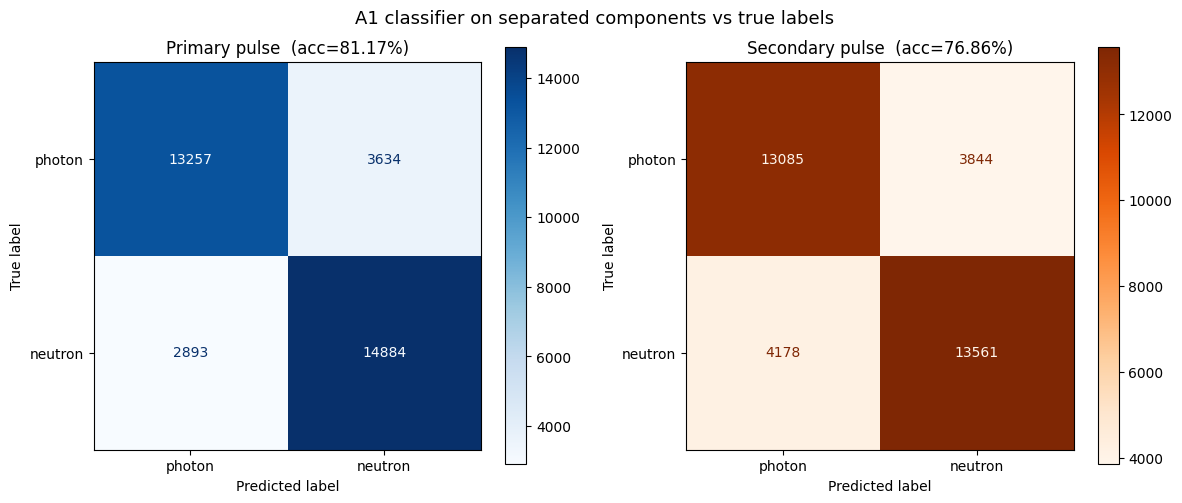

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_pri = confusion_matrix(pri_label_test, pred_pri_label)
disp_pri = ConfusionMatrixDisplay(cm_pri, display_labels=['photon', 'neutron'])
disp_pri.plot(ax=axes[0], cmap='Blues', values_format='d')
acc_pri_cm = cm_pri.diagonal().sum() / cm_pri.sum()
axes[0].set_title(f'Primary pulse  (acc={acc_pri_cm*100:.2f}%)')

cm_sec = confusion_matrix(sec_label_test, pred_sec_label)
disp_sec = ConfusionMatrixDisplay(cm_sec, display_labels=['photon', 'neutron'])
disp_sec.plot(ax=axes[1], cmap='Oranges', values_format='d')
acc_sec_cm = cm_sec.diagonal().sum() / cm_sec.sum()
axes[1].set_title(f'Secondary pulse  (acc={acc_sec_cm*100:.2f}%)')

plt.suptitle('A1 classifier on separated components vs true labels', fontsize=13)
plt.tight_layout()
plt.savefig('figures/a2_separator_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## Confusion matrices and accuracy by inter-pulse delay

How does separation quality depend on how close together the two pulses are?
Short delays (4-10 ns) are the hardest — the pulses overlap almost completely.
Longer delays should be easier to separate.

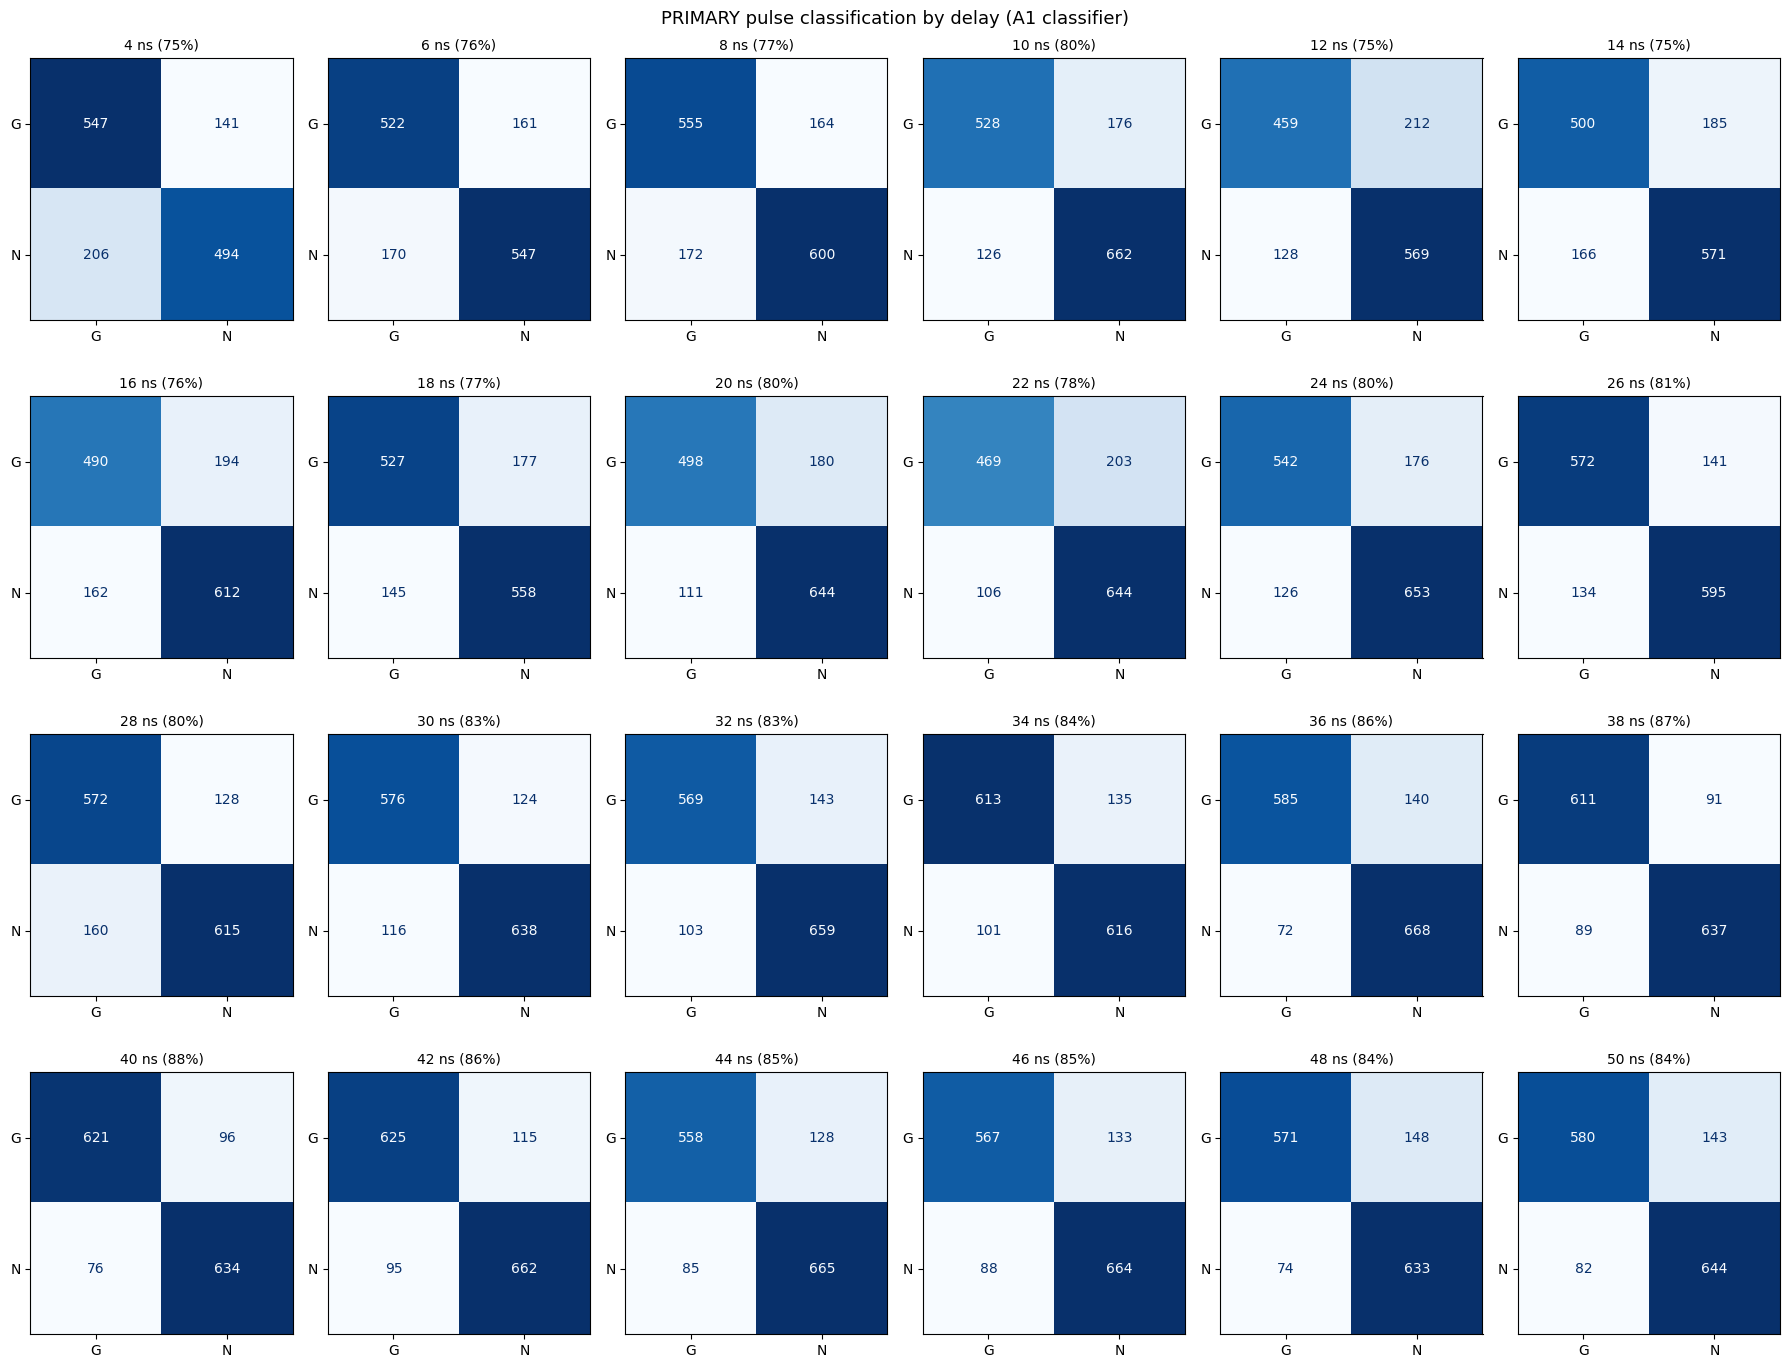

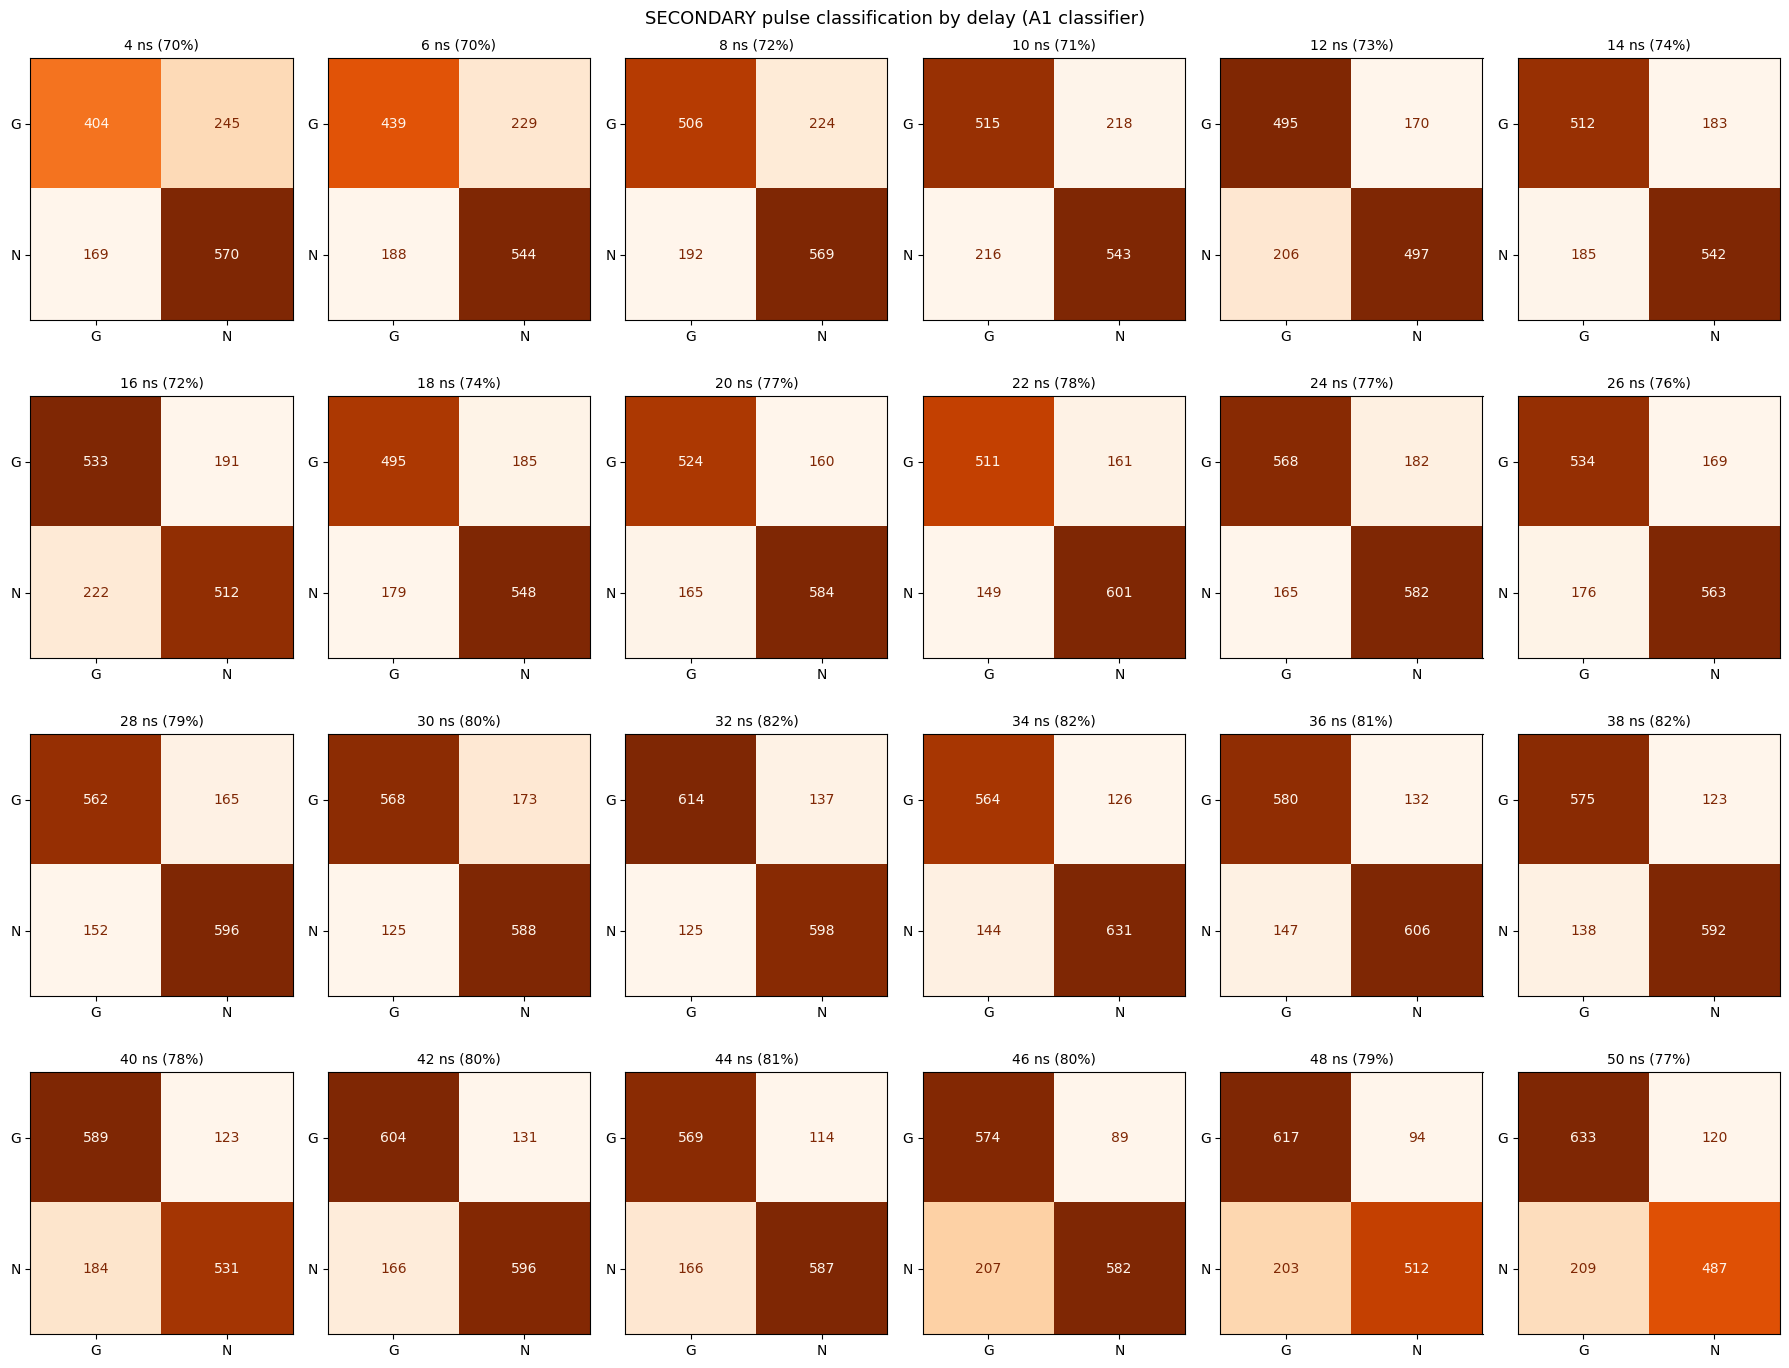

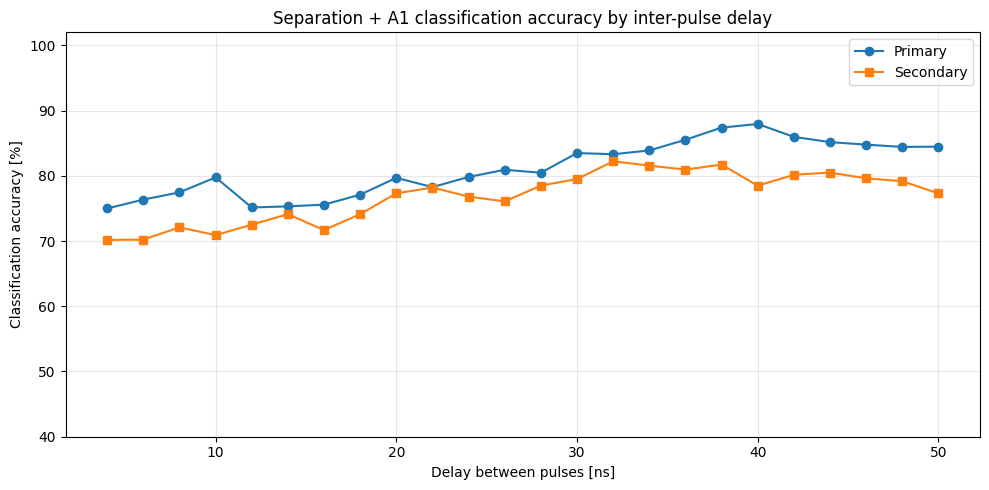

  Delay (ns)     Count     Primary   Secondary
----------------------------------------------
           4      1388      75.00%      70.17%
           6      1400      76.36%      70.21%
           8      1491      77.46%      72.10%
          10      1492      79.76%      70.91%
          12      1368      75.15%      72.51%
          14      1422      75.32%      74.12%
          16      1458      75.58%      71.67%
          18      1407      77.11%      74.13%
          20      1433      79.69%      77.32%
          22      1422      78.27%      78.20%
          24      1497      79.83%      76.82%
          26      1442      80.93%      76.07%
          28      1475      80.47%      78.51%
          30      1454      83.49%      79.50%
          32      1474      83.31%      82.23%
          34      1465      83.89%      81.57%
          36      1465      85.53%      80.96%
          38      1428      87.39%      81.72%
          40      1427      87.95%      78.49%
          42 

In [12]:
unique_delays = np.sort(np.unique(delays_test))
valid_delays = [d for d in unique_delays if (delays_test == d).sum() >= 20]
n_delays = len(valid_delays)

# ── Primary pulse: confusion matrix per delay ──
ncols = min(6, n_delays)
nrows = int(np.ceil(n_delays / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3.5 * nrows))
axes_flat = np.array(axes).flatten() if n_delays > 1 else [axes]

delay_acc_pri = []
delay_acc_sec = []

for i, d in enumerate(valid_delays):
    mask = delays_test == d
    d_ns = d * 2

    cm = confusion_matrix(pri_label_test[mask], pred_pri_label[mask], labels=[0, 1])
    acc = cm.diagonal().sum() / cm.sum() if cm.sum() > 0 else 0
    delay_acc_pri.append(acc)

    if i < len(axes_flat):
        disp = ConfusionMatrixDisplay(cm, display_labels=['G', 'N'])
        disp.plot(ax=axes_flat[i], cmap='Blues', colorbar=False, values_format='d')
        axes_flat[i].set_title(f'{d_ns} ns ({acc*100:.0f}%)', fontsize=10)
        axes_flat[i].set_xlabel('')
        axes_flat[i].set_ylabel('')

for j in range(len(valid_delays), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('PRIMARY pulse classification by delay (A1 classifier)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/a2_separator_delay_cm_primary.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Secondary pulse: confusion matrix per delay ──
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3.5 * nrows))
axes_flat = np.array(axes).flatten() if n_delays > 1 else [axes]

for i, d in enumerate(valid_delays):
    mask = delays_test == d
    d_ns = d * 2

    cm = confusion_matrix(sec_label_test[mask], pred_sec_label[mask], labels=[0, 1])
    acc = cm.diagonal().sum() / cm.sum() if cm.sum() > 0 else 0
    delay_acc_sec.append(acc)

    if i < len(axes_flat):
        disp = ConfusionMatrixDisplay(cm, display_labels=['G', 'N'])
        disp.plot(ax=axes_flat[i], cmap='Oranges', colorbar=False, values_format='d')
        axes_flat[i].set_title(f'{d_ns} ns ({acc*100:.0f}%)', fontsize=10)
        axes_flat[i].set_xlabel('')
        axes_flat[i].set_ylabel('')

for j in range(len(valid_delays), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('SECONDARY pulse classification by delay (A1 classifier)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/a2_separator_delay_cm_secondary.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Accuracy vs delay plot ──
delay_ns_arr = np.array(valid_delays) * 2.0

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(delay_ns_arr, np.array(delay_acc_pri) * 100, 'o-', label='Primary', color='tab:blue')
ax.plot(delay_ns_arr, np.array(delay_acc_sec) * 100, 's-', label='Secondary', color='tab:orange')
ax.set_xlabel('Delay between pulses [ns]')
ax.set_ylabel('Classification accuracy [%]')
ax.set_title('Separation + A1 classification accuracy by inter-pulse delay')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(40, 102)
plt.tight_layout()
plt.savefig('figures/a2_separator_delay_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Summary table ──
print(f"{'Delay (ns)':>12}  {'Count':>8}  {'Primary':>10}  {'Secondary':>10}")
print('-' * 46)
for d, ap, a_s in zip(valid_delays, delay_acc_pri, delay_acc_sec):
    n = (delays_test == d).sum()
    print(f'{d*2:>12}  {n:>8}  {ap:>10.2%}  {a_s:>10.2%}')

## Separation visualizations

Random test pileups with the two separated components overlaid on the true
components. Each subplot shows the original pileup (gray), the true component
(solid), and the predicted component (dashed).

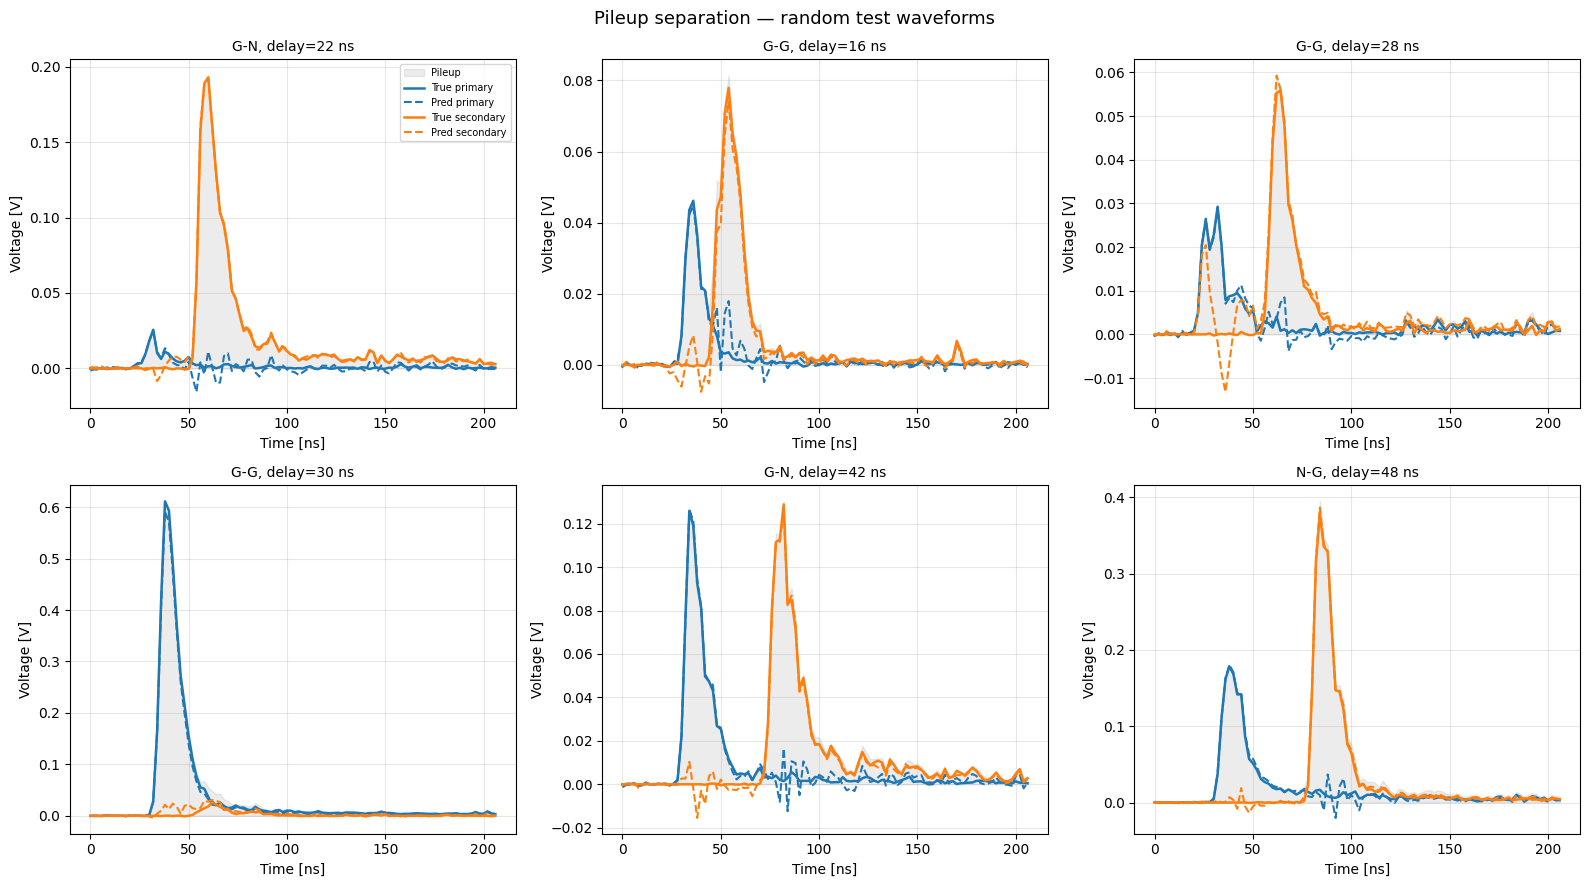

In [13]:
n_plot = 6
rng_plot = np.random.default_rng()
plot_idx = rng_plot.choice(len(X_test), size=n_plot, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, i in zip(axes, plot_idx):
    t = np.arange(N_SAMPLES) * 2.0  # ns
    ax.fill_between(t, X_test[i], alpha=0.15, color='gray', label='Pileup')
    ax.plot(t, Y1_test[i], color='tab:blue', lw=1.8, label='True primary')
    ax.plot(t, pred_primary[i], color='tab:blue', lw=1.5, linestyle='--', label='Pred primary')
    ax.plot(t, Y2_test[i], color='tab:orange', lw=1.8, label='True secondary')
    ax.plot(t, pred_secondary[i], color='tab:orange', lw=1.5, linestyle='--', label='Pred secondary')

    p = 'N' if pri_label_test[i] == 1 else 'G'
    s = 'N' if sec_label_test[i] == 1 else 'G'
    d_ns = delays_test[i] * 2
    c1 = corr_primary[np.where(idx_test == idx_test[i])[0][0]] if i < len(corr_primary) else corr_primary[i]
    ax.set_title(f'{p}-{s}, delay={d_ns} ns', fontsize=10)
    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('Voltage [V]')
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle('Pileup separation — random test waveforms', fontsize=13)
plt.tight_layout()
plt.savefig('figures/a2_separator_reconstructions.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
separator.save('a2_separator.keras')
print('Model saved to a2_separator.keras')

Model saved to a2_separator.keras
